

 Import Essential Libraries



In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import numpy as np
import random
import networkx as nx
import matplotlib.pyplot as plt

Loading Data (Gene Expression File)

In [2]:
data = pd.read_csv('10_1_multifactorial.tsv', sep='\t')

In [3]:
data

,G1,G2,G3,G4,G5,G6,G7,G8,G9,G10
0,0.747265,0.014517,0.276838,0.592492,0.113733,0.419975,0.670462,0.787343,0.585102,0.637932
1,0.195242,0.066668,0.466840,0.766507,0.520145,0.249580,0.327950,0.717085,0.769589,0.654802
2,0.768406,0.139643,0.129935,0.630515,0.001622,0.279522,0.578406,0.620945,0.590976,0.667800
3,0.420029,0.107171,0.339416,0.628433,0.219818,0.329508,0.640160,0.672822,0.471161,0.804312
4,0.647568,0.023660,0.349471,0.540763,0.047735,0.134038,0.503877,0.454244,0.612534,0.682894
5,0.220343,0.187986,0.361879,0.594514,0.441229,0.338426,0.411716,0.565468,0.621208,0.791398
6,0.684484,0.131768,0.152332,0.743353,0.142860,0.328834,0.649431,0.746172,0.848214,0.622901
7,0.512985,0.141392,0.410110,0.649222,0.062865,0.340448,0.403024,0.668617,0.703335,0.657442
8,0.679307,0.222543,0.461603,0.667487,0.031957,0.696353,0.422341,0.024688,0.733915,0.763836
9,0.411451,0.264898,0.538770,0.732208,0.266095,0.622011,0.179241,0.122529,0.693727,0.835620


Using K-means Clustering for each Column(Gene) to Discretize the Data

In [4]:
def discretize_data(data):
    discretized_data = pd.DataFrame()
    kmeans = KMeans(n_clusters=2, random_state=0)
    for col in data.columns:
        labels = kmeans.fit_predict(data[[col]])
        discretized_data[col] = labels
    return discretized_data

In [5]:
discretized_data = discretize_data(data)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

In [6]:
discretized_data

,G1,G2,G3,G4,G5,G6,G7,G8,G9,G10
0,1,1,1,1,0,0,1,0,0,1
1,0,1,0,0,1,0,0,0,1,1
2,1,0,1,1,0,0,1,0,0,1
3,0,1,0,1,0,0,1,0,0,0
4,1,1,0,1,0,0,1,0,0,1
5,0,0,0,1,1,0,0,0,0,0
6,1,0,1,0,0,0,1,0,1,1
7,1,0,0,1,0,0,0,0,1,1
8,1,0,0,1,0,1,0,1,1,0
9,0,0,0,0,0,1,0,1,1,0


Calculate Conditional Probability Tables (Confugurations)

In [7]:
def calculate_cpt(data, model):
    # an empty dictionary for CPTs
    cpts = {}

    # For each gene
    for i in range(model.shape[0]):
        # indices of the gene's parents
        parents = np.where(model[i] == 1)[0]

        # count each config
        counts = {}

        # For each data point
        for j in range(data.shape[0]):
            # state of the gene and its parents
            gene_state = data.iloc[j, i]
            parent_state = tuple(data.iloc[j, parents])

            # add the count for this config
            state_count = counts.get(parent_state, {0: 0, 1: 0})
            state_count[gene_state] += 1
            counts[parent_state] = state_count

        # probabilities for each config
        probabilities = {}

        # For each parent state
        for parent_state in counts:
            # the total count for this parent state
            total_count = sum(counts[parent_state].values())

            # the probabilities for each gene state
            gene_probabilities = {gene_state: count / total_count for gene_state, count in counts[parent_state].items()}

            # Add the probabilities to the CPT
            probabilities[parent_state] = gene_probabilities

        # Add the CPT to the dictionary of CPTs
        cpts[i] = probabilities

    return cpts

 Test the function

In [8]:
test_model = np.array([[0, 1, 0], [0, 0, 1], [1, 0, 0]])

In [9]:
test_model

array([[0, 1, 0],
       [0, 0, 1],
       [1, 0, 0]])

In [10]:
calculate_cpt(discretized_data, test_model)

{0: {(1,): {0: 0.5, 1: 0.5},
  (0,): {0: 0.3333333333333333, 1: 0.6666666666666666}},
 1: {(1,): {0: 0.6666666666666666, 1: 0.3333333333333333},
  (0,): {0: 0.5714285714285714, 1: 0.42857142857142855}},
 2: {(1,): {0: 0.5, 1: 0.5}, (0,): {0: 1.0, 1: 0.0}}}

Calculate Log-Likelihood (How much each model (graph structure/adjacency matrix) is probable given the data (gene expression dataset)

In [11]:
def calculate_log_likelihood(data, model):
    # the CPTs for the model
    cpts = calculate_cpt(data, model)

    # Initialize the log-likelihood
    log_likelihood = 0

    # For each data point
    for i in range(data.shape[0]):
        # For each gene
        for j in range(data.shape[1]):
            # state of the gene and its parents
            gene_state = data.iloc[i, j]
            parent_state = tuple(data.iloc[i, np.where(model[j] == 1)[0]])

            # Add the log of the conditional probability of the gene state given the parent state to the log-likelihood
            log_likelihood += np.log(cpts[j][parent_state][gene_state])

    return log_likelihood


Test the function

In [12]:
test_model_2 = np.zeros((10, 10))
for i in range(10):
    test_model_2[i, i-1] = 1

In [13]:
calculate_log_likelihood(discretized_data, test_model_2)

-53.66946148242739

How to propose a new model given the current model using add, delete or reverse edges)

In [14]:
def propose_new_model(current_model):

    new_model = current_model.copy()

    # add, remove, or reverse randomly
    operation = random.choice(['add', 'remove', 'reverse'])


    if operation == 'add':
        # Choose two unconnected nodes
        available_nodes = np.argwhere(new_model == 0)
        if len(available_nodes) > 0:
            i, j = random.choice(available_nodes)
            # Add the edge
            new_model[i, j] = 1

    elif operation == 'remove':
        # where are edges?
        existing_edges = np.argwhere(new_model == 1)
        if len(existing_edges) > 0:
            i, j = random.choice(existing_edges)
            # Remove the edge
            new_model[i, j] = 0

    elif operation == 'reverse':
        # where are edges?
        existing_edges = np.argwhere(new_model == 1)
        if len(existing_edges) > 0:
            i, j = random.choice(existing_edges)
            # Reverse the edge
            new_model[i, j] = 0
            new_model[j, i] = 1

    return new_model

Test the function

In [15]:
propose_new_model(test_model_2)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]])

Check if the graph is cyclic (to be rejected later)

In [16]:
def is_cyclic(model):
    graph = nx.DiGraph(model)
    cycles = list(nx.simple_cycles(graph))
    return len(cycles) > 0

In [17]:
is_cyclic(test_model_2)

True

Metropolis Hastings Algorithm using acceptance probability

In [18]:
def metropolis_hastings(data, iterations):
    # Number of nodes
    n = data.shape[1]

    # initialization
    current_model = np.zeros((n, n))

    models = []
    log_likelihoods = []


    for _ in range(iterations):
        # Propose
        proposed_model = propose_new_model(current_model)

        # If cyclic, reject
        if is_cyclic(proposed_model):
            continue

        # the log-likelihoods of the data given the current and proposed models
        current_log_likelihood = calculate_log_likelihood(data, current_model)
        proposed_log_likelihood = calculate_log_likelihood(data, proposed_model)

        # the acceptance probability formulation
        acceptance_probability = min(1,np.exp(proposed_log_likelihood - current_log_likelihood))

        # Accept or reject
        if random.random() < acceptance_probability:
            current_model = proposed_model
            models.append(current_model)
            log_likelihoods.append(current_log_likelihood)

    return models, log_likelihoods

Run Metropolis-Hastings three times, guess burn-in period based on the plot, and calculate an average burn-in period

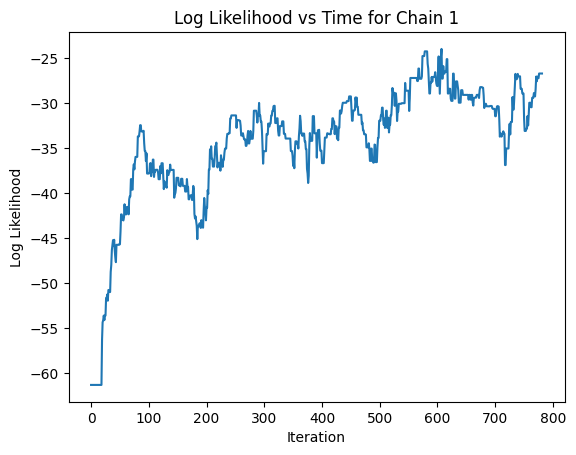

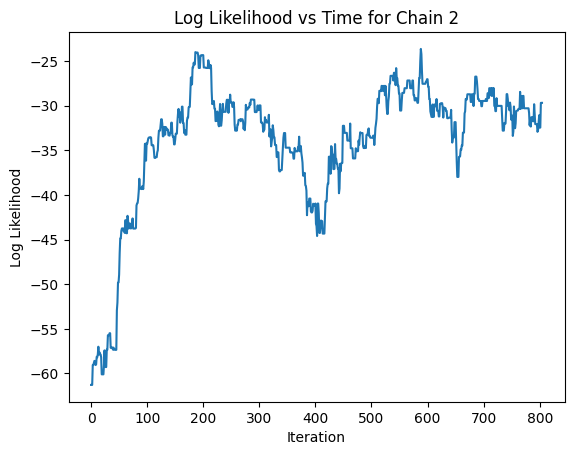

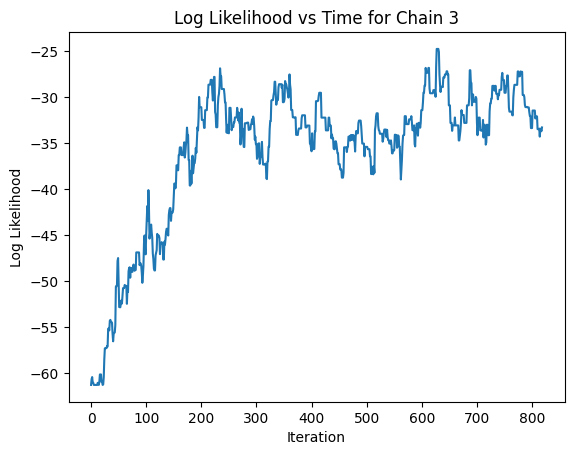

Enter your guess for the burn-in period: 250
Average Burn-in Period:  233


In [19]:
num_chains = 3
burn_in_guesses = []

for i in range(num_chains):
    np.random.seed(i)  # Use a different seed for each chain
    models, log_likelihoods = metropolis_hastings(discretized_data, 2000)

    plt.plot(log_likelihoods)
    plt.xlabel('Iteration')
    plt.ylabel('Log Likelihood')
    plt.title('Log Likelihood vs Time for Chain {}'.format(i+1))
    plt.show()

    # my burn-in guesses
    burn_in_guess = int(input("Enter your guess for the burn-in period: "))
    burn_in_guesses.append(burn_in_guess)

# the average burn-in period
average_burn_in = int(np.mean(burn_in_guesses))
print("Average Burn-in Period: ", average_burn_in)


Averaging the models after average burn-in period, and using a threshold to make the model binary (to find out where the edges are)

In [20]:
def average_models(models, burn_in):
    # Ignore the burn-in
    models_after_burn_in = models[burn_in:]

    # mean of models
    mean_of_models = np.mean(models_after_burn_in, axis=0)

    # Threshold to get a binary matrix
    averaged_model = (mean_of_models > 0.5).astype(int)

    return averaged_model


In [21]:
averaged_model = average_models(models,average_burn_in)


In [22]:
averaged_model

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 1, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

Comparing the True Model (gold file) and the average model (which was predicted)

In [23]:
true_model = pd.read_csv('10_01_gold.txt', index_col=0).values

In [24]:
true_model

array([[0, 0, 1, 1, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 1, 1, 0, 0, 0, 0, 0, 0]])

In [25]:
# TP, TN, FP, FN
TP = np.sum((averaged_model == 1) & (true_model == 1))
TN = np.sum((averaged_model == 0) & (true_model == 0))
FP = np.sum((averaged_model == 1) & (true_model == 0))
FN = np.sum((averaged_model == 0) & (true_model == 1))

In [26]:
TP, TN, FP, FN

(1, 83, 3, 13)

Calculate Evaluation Metrics

In [27]:
# Precision
if TP + FP != 0:
    precision = TP / (TP + FP)
else:
    precision = np.nan


# Recall
recall = TP / (TP + FN)

# Accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)

# F1 Score
f1_score = 2 * precision * recall / (precision + recall)

In [28]:
precision, recall, accuracy, f1_score

(0.25, 0.07142857142857142, 0.84, 0.11111111111111112)

How do models look like?

In [29]:
def plot_graph(model, title):
    G = nx.DiGraph()

    # Convert matrix to list of edges
    n = model.shape[0]
    edges = np.argwhere(model == 1)
    edges = [(edges[i, 0], edges[i, 1]) for i in range(edges.shape[0])]

    G.add_edges_from(edges)

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G)
    nx.draw_networkx(G, pos, with_labels=True, node_color='lightblue', edge_color='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

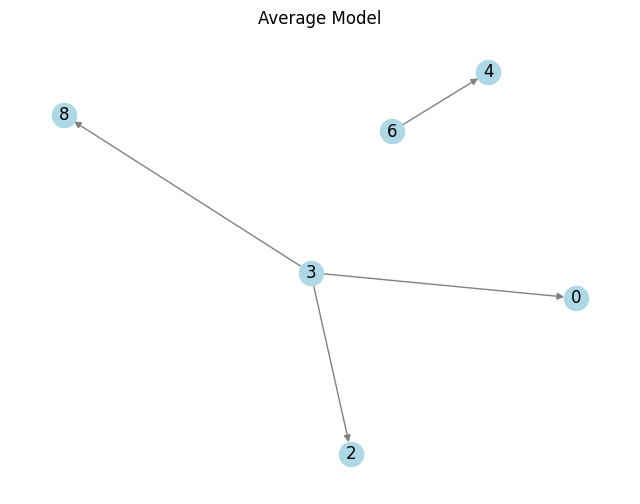

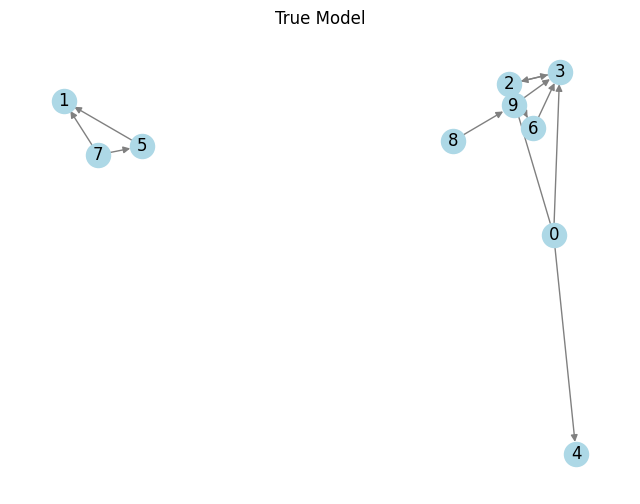

In [30]:
plot_graph(averaged_model, 'Average Model')
plot_graph(true_model, 'True Model')